In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/EDA_DEAP.ipynb
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s20.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s17.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s31.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s14.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s32.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s28.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s24.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s18.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s22.dat
/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python/s02.dat
/kaggl

Loading EEG data...
Training Global EEG Observer...
Epoch 1 Loss: 1.2501
Epoch 2 Loss: 1.0526
Epoch 3 Loss: 1.0338
Epoch 4 Loss: 1.0193
Epoch 5 Loss: 1.0105
Epoch 6 Loss: 1.0056
Epoch 7 Loss: 0.9879
Epoch 8 Loss: 0.9829
Epoch 9 Loss: 0.9648
Epoch 10 Loss: 0.9505


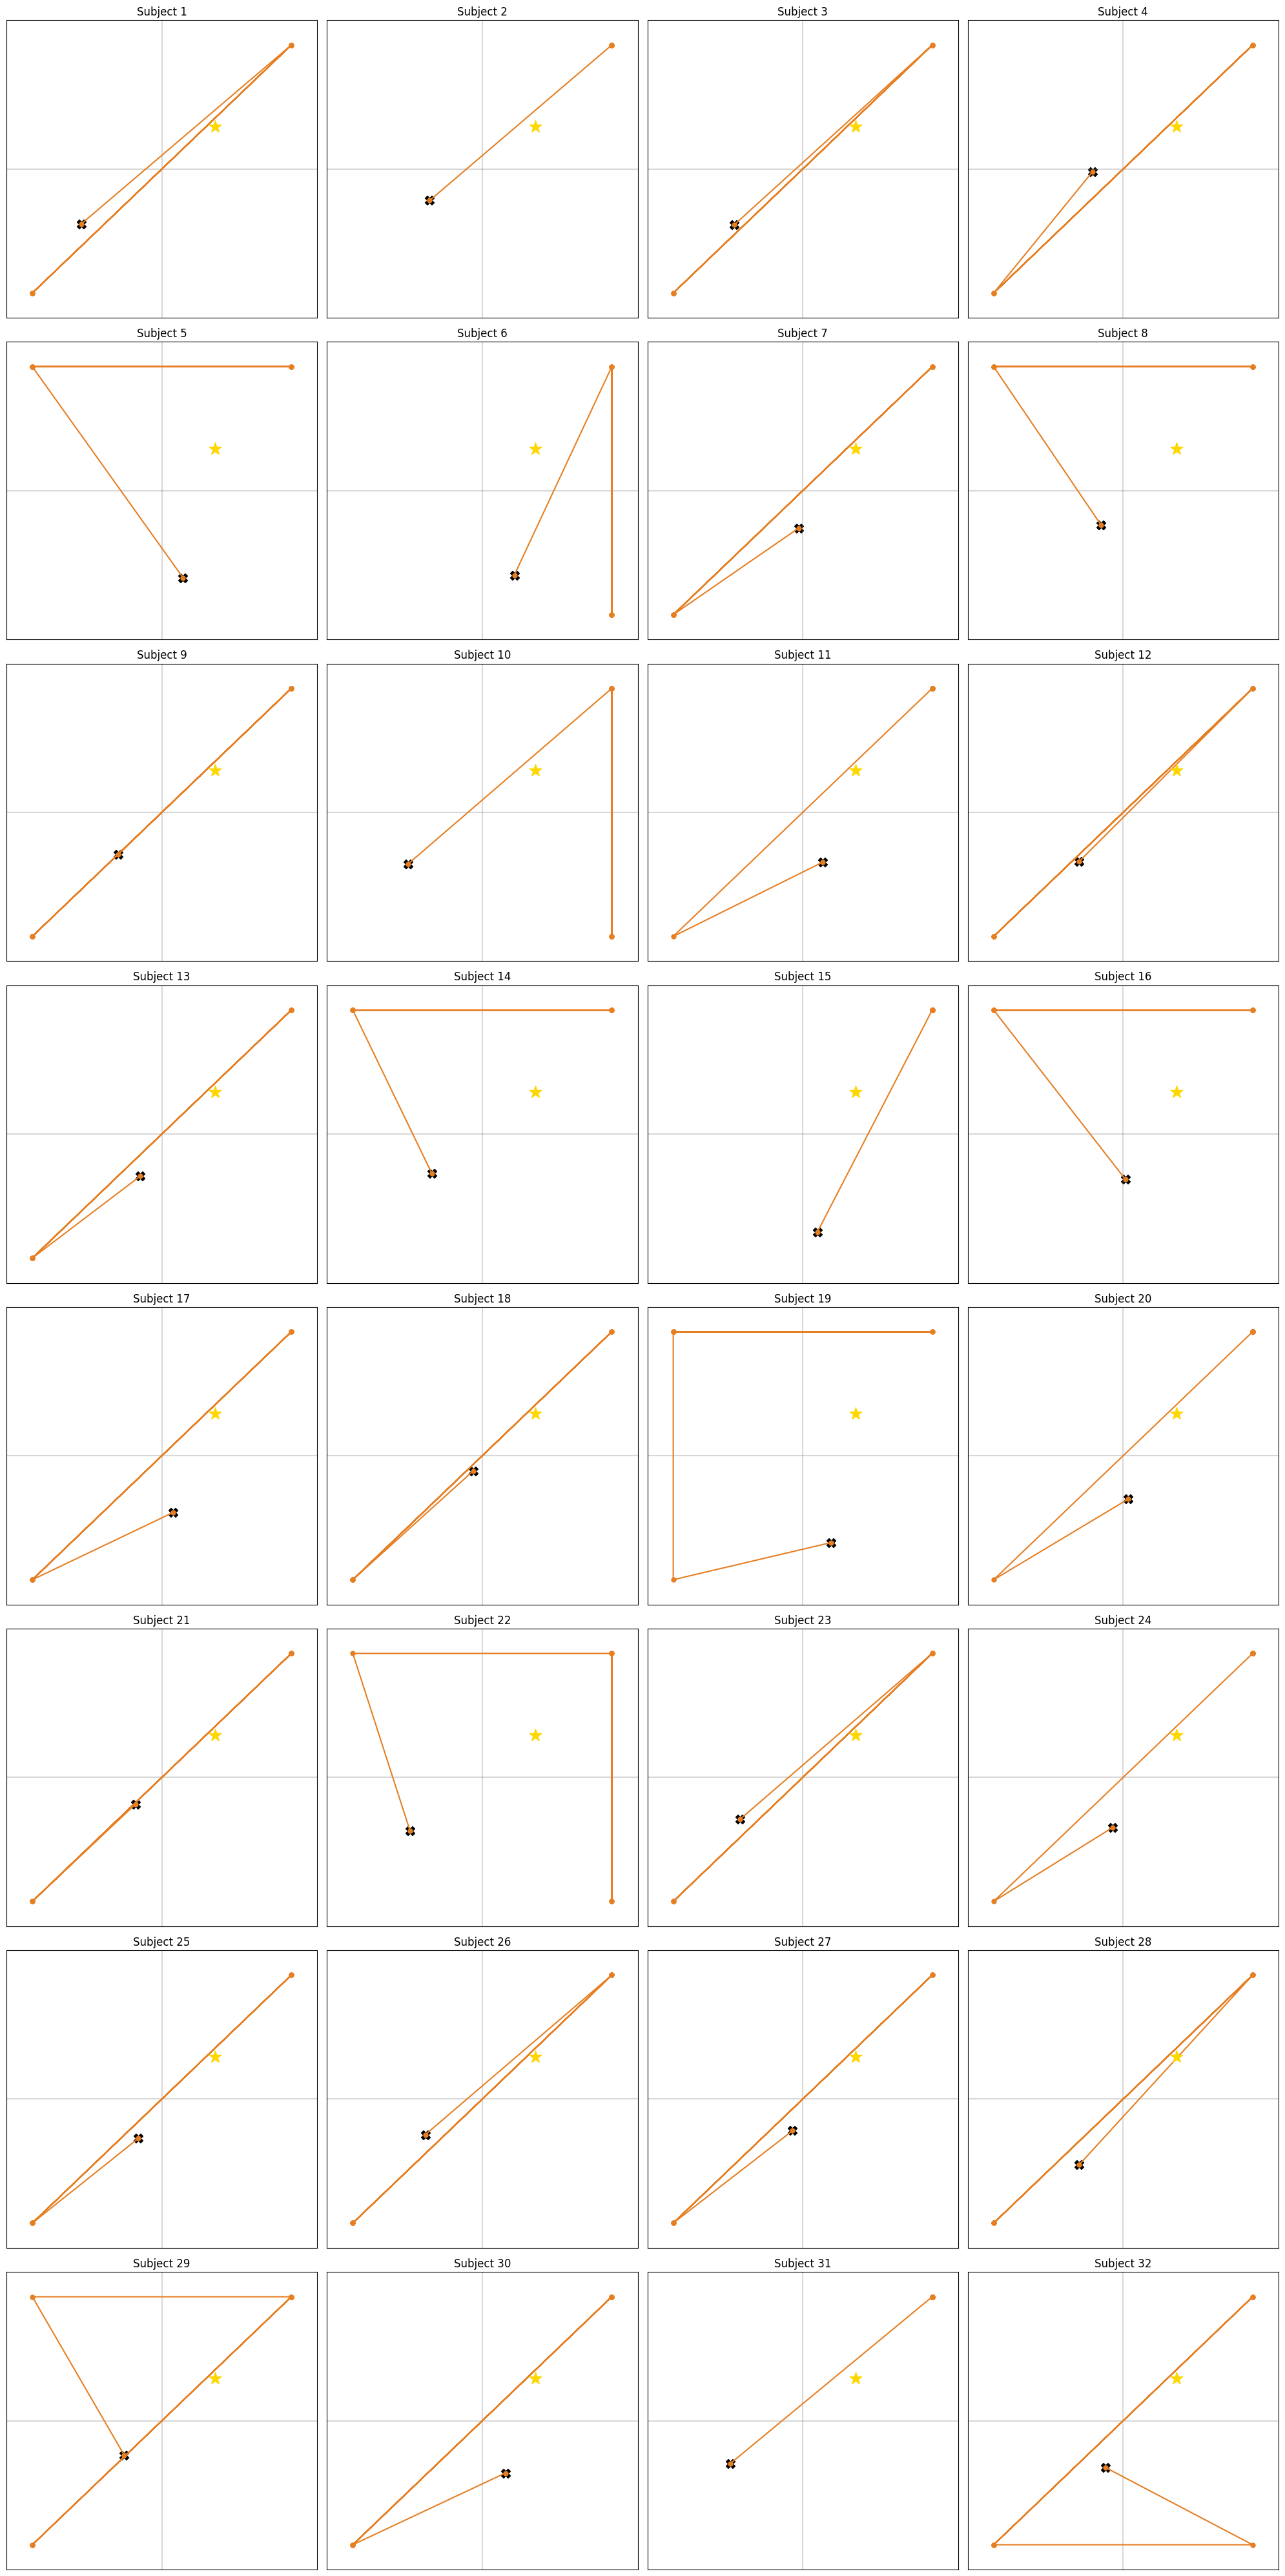


PERFORMANCE REPORT
         Agent   Convergence AVERAGE ANGLE ERROR AVERAGE DISTANCE ERROR              States
Simple Q-Table 21/32 (65.6%)              55.44°                   1.21 8 Discrete Emotions


In [12]:
import pickle
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/kaggle/input/datasets/manh123df/deap-dataset/deap-dataset/data_preprocessed_python"
SAVE_DIR = "./simple_q_results"
os.makedirs(SAVE_DIR, exist_ok=True)

# Q-Learning Hyperparameters
ALPHA = 0.1       # Learning rate for Table update
GAMMA = 0.6       # Discount factor
EPSILON = 0.1    # Exploration rate
TRAIN_EPISODES = 12 
NUM_CLIPS = 6     # regulation steps
# State Definitions (8 Emotions)
EMOTIONS = [
    "Relief",
    "Disgust",
    "Pride",
    "Interest",
    "Happy",
    "Anger",
    "Guilt",
    "Sadness"
]

EMOTION_CENTROIDS = np.array([
    [0.14, -0.05],   # Relief
    [-0.45, -0.41],  # Disgust
    [0.53, -0.06],   # Pride
    [-0.07, 0.30],   # Interest
    [0.41, 0.34],    # Happy
    [-0.50, 0.29],   # Anger
    [0.06, -0.55],   # Guilt
    [-0.14, -0.21]   # Sadness
])

CLUSTER_STATS = {
    "Relief":  {"mean": 0.1474, "min": 0.0543, "max": 0.2269},
    "Disgust": {"mean": 0.1353, "min": 0.0799, "max": 0.2158},
    "Pride":   {"mean": 0.1108, "min": 0.0645, "max": 0.2286},
    "Interest":{"mean": 0.1532, "min": 0.0738, "max": 0.2130},
    "Happy":   {"mean": 0.1724, "min": 0.1006, "max": 0.3243},
    "Anger":   {"mean": 0.1224, "min": 0.0357, "max": 0.2857},
    "Guilt":   {"mean": 0.1488, "min": 0.0768, "max": 0.2595},
    "Sadness": {"mean": 0.1273, "min": 0.0396, "max": 0.2401},
}

EMOTION_COVS = {}

for emotion in EMOTIONS:
    stats = CLUSTER_STATS[emotion]
    
    # Estimate variance from mean distance
    var = stats["mean"] ** 2
    
    # 2x2 isotropic covariance matrix
    cov = np.array([
        [var, 0],
        [0, var]
    ])
    
    EMOTION_COVS[emotion] = cov
    

TARGET_COORDS = EMOTION_CENTROIDS[EMOTIONS.index("Happy")]

# ---------------- 1. DATA LOADING ----------------
def load_all_subjects(path):
    subjects = {}
    print("Loading EEG data...")
    for i in range(1, 33):
        f_name = os.path.join(path, f"s{i:02d}.dat")
        if os.path.exists(f_name):
            with open(f_name, 'rb') as f:
                data = pickle.load(f, encoding='latin1')
                eeg = data['data'][:, :32, :]
                labels = (data['labels'][:, :2] - 5) / 4.0 # Scale to [-1, 1]
                subjects[i-1] = (eeg, labels)
    return subjects

# Emotion sampling functions
def sample_from_gaussian_emotion(emotion_name):
    idx = EMOTIONS.index(emotion_name)
    mean = EMOTION_CENTROIDS[idx]
    cov = EMOTION_COVS[emotion_name]
    stats = CLUSTER_STATS[emotion_name]

    for _ in range(10):  # try multiple times
        sample = np.random.multivariate_normal(mean, cov)
        dist = np.linalg.norm(sample - mean)
        
        if stats["min"] <= dist <= stats["max"]:
            return np.clip(sample, -1, 1)
    
    # fallback
    return mean

def get_distance(pos):
    return (np.linalg.norm(TARGET_COORDS - pos))
    
# ---------------- 2. EEG OBSERVER (NN) ----------------
# This part stays NN because raw EEG is too complex for a simple table
class EEGEmotionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*8064, 256),
            nn.ReLU(),
            nn.Linear(256, 2),
            nn.Tanh()
        ).to(device)

    def forward(self, x): return self.net(x)

def train_observer(subjects_data):
    print("Training Global EEG Observer...")
    X_all = np.concatenate([subjects_data[i][0] for i in range(len(subjects_data))])
    y_all = np.concatenate([subjects_data[i][1] for i in range(len(subjects_data))])
    
    model = EEGEmotionNet()
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    X = torch.FloatTensor(X_all).to(device)
    y = torch.FloatTensor(y_all).to(device)
    
    for epoch in range(10): # Small epoch for speed
        pred = model(X)
        loss = loss_fn(pred, y)
        opt.zero_grad(); loss.backward(); opt.step()
        print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")
    return model

# ---------------- 3. SIMPLE Q-LEARNING LOGIC ----------------

def get_discrete_state(va_coords):
    """Calculates which of the 8 emotions is closest to current VA."""
    dists = np.linalg.norm(EMOTION_CENTROIDS - va_coords, axis=1)
    return np.argmin(dists)

def run_simple_q_comparison(subjects_data, observer):
    results = {}
    
    for sub_id in range(32):
        print(f"Training Subject {sub_id+1}/32", end="\r")
        eeg, _ = subjects_data[sub_id]
        
        # Initialize Q-Table: 8 states (emotions) x 40 actions (clips)
        q_table = np.zeros((8, 40))
        
        # Training Phase
        for _ in range(TRAIN_EPISODES):

            rand_idx = random.randint(0, 39)
            sample = torch.FloatTensor(eeg[rand_idx]).unsqueeze(0).to(device)
            with torch.no_grad():
                v, a = observer(sample).cpu().numpy()[0]

            state = get_discrete_state([v, a])
            
            for _ in range(NUM_CLIPS):
                # Epsilon-Greedy
                if random.random() < EPSILON:
                    action = random.randint(0, 39)
                else:
                    action = np.argmax(q_table[state])
                
                # Use Observer to predict next VA state
                with torch.no_grad():
                    sample = torch.FloatTensor(eeg[action]).unsqueeze(0).to(device)
                    next_va = observer(sample).cpu().numpy()[0]
                
                next_state = get_discrete_state(next_va)
                
                # Reward: Reach Happy (index 0) = +20, otherwise small penalty
                reward = 20 if next_state == EMOTIONS.index("Happy") else -1
                # phi = -100 if np.array_equal(next_state, state) else 0
                phi = -100 if next_state==state else 0
                
                # --- THE SIMPLE Q-UPDATE RULE ---
                old_q = q_table[state, action]
                max_future_q = np.max(q_table[next_state])
                q_table[state, action] = (1 - ALPHA) * old_q + ALPHA * (reward + GAMMA * max_future_q)
                
                state = next_state

        # Evaluation Phase (Testing the trained table)

        # target emotions
        start_emotions = ["Disgust", "Guilt", "Sadness"]

        # get indices of those emotions
        indices = [EMOTIONS.index(e) for e in start_emotions]

        chosen_emotion = random.choice(start_emotions)
        curr_va = sample_from_gaussian_emotion(chosen_emotion)
        
        path = [curr_va]
        
        for _ in range(NUM_CLIPS):
            s_idx = get_discrete_state(curr_va)
            best_action = np.argmax(q_table[s_idx])
            
            with torch.no_grad():
                sample = torch.FloatTensor(eeg[best_action]).unsqueeze(0).to(device)
                curr_va = observer(sample).cpu().numpy()[0]
            path.append(curr_va)
        
        # Calculate final error vs Happy Target [0.8, 0.8]
        final_err = np.degrees(np.arccos(np.clip(np.dot(curr_va/np.linalg.norm(curr_va), TARGET_COORDS/np.linalg.norm(TARGET_COORDS)), -1, 1)))
        
        results[sub_id] = {
            "SimpleQ": {
                'path': np.array(path),
                'err': final_err,
                'dist': get_distance(curr_va),
                'conv': final_err < 30
            }
        }
    return results

# ---------------- 4. VISUALIZATION & REPORT ----------------

def plot_grid(results):
    fig, axes = plt.subplots(8, 4, figsize=(20, 40))
    axes = axes.flatten()
    target = EMOTION_CENTROIDS[EMOTIONS.index("Happy")]

    for sub_id in range(32):
        ax = axes[sub_id]
        ax.axhline(0, color='grey', alpha=0.3); ax.axvline(0, color='grey', alpha=0.3)
        
        path = results[sub_id]["SimpleQ"]['path']
        ax.plot(path[:,0], path[:,1], '-o', color="#e67e22", markersize=5, label="Simple Q")
        
        ax.scatter(target[0], target[1], marker='*', color='gold', s=200, zorder=5)
        ax.scatter(path[0,0], path[0,1], marker='X', color='black', s=100)

        # ax.scatter(TARGET_COORDS[0], TARGET_COORDS[1], marker='*', color='gold', s=150, zorder=5)
        
        ax.set_title(f"Subject {sub_id+1}")
        ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

def print_report(results):
    res_list = [results[s]["SimpleQ"] for s in range(32)]
    conv_rate = sum(1 for r in res_list if r['conv'])
    all_errs = [r['err'] for r in res_list]
    dist = [r['dist'] for r in res_list]
    
    
    df = pd.DataFrame([{
        "Agent": "Simple Q-Table",
        "Convergence": f"{conv_rate}/32 ({(conv_rate/32)*100:.1f}%)",
        "AVERAGE ANGLE ERROR": f"{np.mean(all_errs):.2f}°",
        "AVERAGE DISTANCE ERROR": f"{np.mean(dist):.2f}",
        "States": "8 Discrete Emotions"
    }])
    print("\n" + "="*50 + "\nPERFORMANCE REPORT\n" + "="*50)
    print(df.to_string(index=False))

# ---------------- RUN ----------------
if os.path.exists(DATA_PATH):
    # 1. Load Data
    full_data = load_all_subjects(DATA_PATH)
    
    # 2. Train EEG Observer
    observer_model = train_observer(full_data)
    
    # 3. Train Simple Q-Table for all subjects
    final_results = run_simple_q_comparison(full_data, observer_model)
    
    # 4. Generate Output (Grid and Table)
    plot_grid(final_results)
    print_report(final_results)
else:
    print("Data not found. Please attach the DEAP dataset in Kaggle.")